In [4]:

!pip install gym stable-baselines3


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (upload if needed)
df = pd.read_csv('./train.csv')  # Change this if you load it differently

# Let's check the columns
print(df.columns)

# Select relevant features
features = ['pv_production', 'wind_production', 'consumption', 'spot_market_price']
data = df[features].copy().dropna().reset_index(drop=True)

# Normalize inputs (you can also try standardization)
data_norm = (data - data.min()) / (data.max() - data.min())


Index(['time', 'pv_production', 'wind_production', 'consumption',
       'spot_market_price', 'precip_1h:mm', 'precip_type:idx',
       'prob_precip_1h:p', 'clear_sky_rad:W', 'clear_sky_energy_1h:J',
       'diffuse_rad:W', 'diffuse_rad_1h:Wh', 'direct_rad:W',
       'direct_rad_1h:Wh', 'global_rad:W', 'global_rad_1h:Wh',
       'sunshine_duration_1h:min', 'sun_azimuth:d', 'sun_elevation:d',
       'low_cloud_cover:p', 'medium_cloud_cover:p', 'high_cloud_cover:p',
       'total_cloud_cover:p', 'effective_cloud_cover:p', 'temp',
       'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d'],
      dtype='object')


In [13]:
# Define action space:
# 0 = use only local production
# 1 = use battery (if available)
# 2 = use hydrogen (if available)
# 3 = import from grid

n_actions = 4
battery_capacity = 500  # in kWh
hydrogen_capacity = 1670  # in kWh

# Define state as [pv, wind, consumption, battery_level, hydrogen_level]
def get_state(row, battery_level, hydrogen_level):
    return np.array([
        row['pv_production'],
        row['wind_production'],
        row['consumption'],
        battery_level / battery_capacity,
        hydrogen_level / hydrogen_capacity
    ])

# Define a reward function
def compute_reward(row, action, battery_level, hydrogen_level):
    demand = row['consumption']
    supply = row['pv_production'] + row['wind_production']
    spot_price = row['spot_market_price']
    
    # Action cost logic
    if action == 0:  # Try to use local production
        if supply >= demand:
            return 0  # free!
        else:
            return - (demand - supply) * spot_price
    elif action == 1:  # Use battery
        if battery_level >= demand:
            return -0.01 * demand  # small cost
        else:
            return - (demand - battery_level) * spot_price
    elif action == 2:  # Use hydrogen
        if hydrogen_level >= demand:
            return -0.05 * demand
        else:
            return - (demand - hydrogen_level) * spot_price
    elif action == 3:  # Import from grid
        return - demand * spot_price


In [15]:
!pip install "shimmy>=2.0"


In [18]:
!pip install gymnasium

In [19]:
# 📦 Imports
import gym
from gym import spaces
import numpy as np
from stable_baselines3 import DQN

# 👷 Custom Environment using the dataset
class MicrogridEnv(gym.Env):
    def __init__(self, data):
        super().__init__()
        self.data = data
        self.idx = 0
        self.battery = 0
        self.hydrogen = 0

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(5,), dtype=np.float32
        )

    def reset(self):
        self.idx = 0
        self.battery = 0
        self.hydrogen = 0
        return get_state(self.data.iloc[self.idx], self.battery, self.hydrogen)

    def step(self, action):
        row = self.data.iloc[self.idx]
        reward = compute_reward(row, action, self.battery, self.hydrogen)

        supply = row['pv_production'] + row['wind_production']
        demand = row['consumption']

        if action == 1:
            self.battery = max(0, self.battery - demand)
        elif action == 2:
            self.hydrogen = max(0, self.hydrogen - demand)
        elif action == 0 and supply > demand:
            extra = supply - demand
            self.battery = min(battery_capacity, self.battery + 0.5 * extra)
            self.hydrogen = min(hydrogen_capacity, self.hydrogen + 0.1 * extra)

        self.idx += 1
        done = self.idx >= len(self.data) - 1
        next_state = get_state(self.data.iloc[self.idx], self.battery, self.hydrogen)
        return next_state, reward, done, {}

# 📊 Prepare environment and train DQN
env = MicrogridEnv(data_norm)
dqn_model = DQN("MlpPolicy", env, verbose=1)
dqn_model.learn(total_timesteps=10000)
dqn_model.save("dqn_microgrid_dataset")

# ✅ Evaluate
obs = env.reset()
rewards = []
done = False
while not done:
    action, _ = dqn_model.predict(obs)
    obs, reward, done, _ = env.step(action)
    rewards.append(reward)

print("DQN Total reward:", np.sum(rewards))


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN Total reward: -8.569823396493813


In [20]:
# Discretize continuous state
def discretize(state, bins=5):ju
    return tuple((state * bins).astype(int))

# Initialize Q-tables
q_table_q = {}
q_table_sarsa = {}

episodes = 500
epsilon = 1.0
alpha = 0.1
gamma = 0.95
epsilon_decay = 0.99

for algo in ['q', 'sarsa']:
    rewards_all = []
    for ep in range(episodes):
        idx = 0
        battery = 0
        hydrogen = 0
        total_reward = 0

        row = data_norm.iloc[idx]
        state = discretize(get_state(row, battery, hydrogen))

        if algo == 'sarsa':
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(q_table_sarsa.get(state, np.zeros(n_actions)))

        while idx < len(data_norm) - 1:
            row = data_norm.iloc[idx]
            reward = compute_reward(row, action if algo=='sarsa' else 0, battery, hydrogen)
            next_idx = idx + 1
            next_row = data_norm.iloc[next_idx]
            
            next_state_raw = get_state(next_row, battery, hydrogen)
            next_state = discretize(next_state_raw)

            if algo == 'q':
                if np.random.rand() < epsilon:
                    action = np.random.randint(n_actions)
                else:
                    action = np.argmax(q_table_q.get(state, np.zeros(n_actions)))
                best_next = np.max(q_table_q.get(next_state, np.zeros(n_actions)))
                q_table_q[state] = q_table_q.get(state, np.zeros(n_actions))
                q_table_q[state][action] += alpha * (reward + gamma * best_next - q_table_q[state][action])
            else:
                q_table_sarsa[state] = q_table_sarsa.get(state, np.zeros(n_actions))
                if np.random.rand() < epsilon:
                    next_action = np.random.randint(n_actions)
                else:
                    next_action = np.argmax(q_table_sarsa.get(next_state, np.zeros(n_actions)))
                q_table_sarsa[state][action] += alpha * (reward + gamma * q_table_sarsa.get(next_state, np.zeros(n_actions))[next_action] - q_table_sarsa[state][action])
                action = next_action

            total_reward += reward
            state = next_state
            idx = next_idx

        epsilon *= epsilon_decay
        rewards_all.append(total_reward)
    
    print(f"{algo.upper()} Learning Reward (last 10 avg):", np.mean(rewards_all[-10:]))


Q Learning Reward (last 10 avg): -2.5306680870372738
SARSA Learning Reward (last 10 avg): -2.544506992118646


In [21]:
# Re-create the environment for clean evaluation
eval_env = MicrogridEnv(data_norm)

obs = eval_env.reset()
dqn_rewards = []
dqn_actions = []
done = False

while not done:
    action, _ = dqn_model.predict(obs)
    obs, reward, done, _ = eval_env.step(action)
    dqn_rewards.append(reward)
    dqn_actions.append(action)

print("✅ DQN Total Reward:", np.sum(dqn_rewards))


✅ DQN Total Reward: -9.84933249827797


\\?\C:\Users\luthi\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


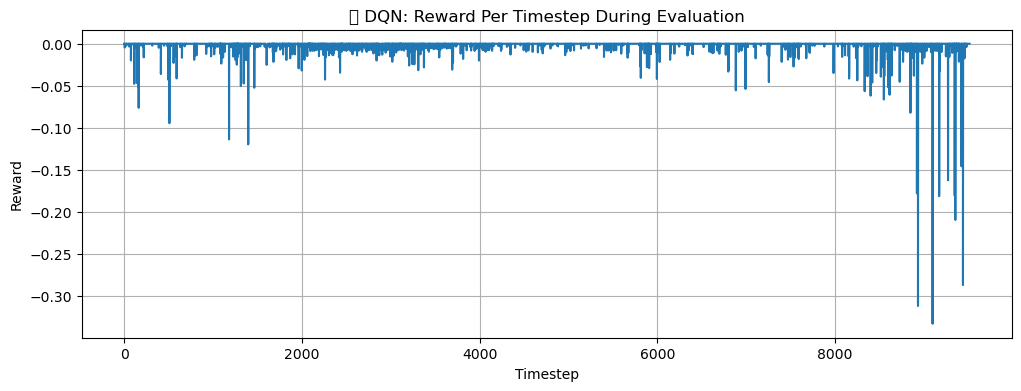

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(dqn_rewards)
plt.title("📈 DQN: Reward Per Timestep During Evaluation")
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.grid(True)
plt.show()


In [23]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(x=dqn_actions, palette="viridis")
plt.title("🔢 DQN: Action Distribution During Evaluation")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks([0, 1, 2, 3], ['Use Local', 'Battery', 'Hydrogen', 'Import Grid'])
plt.grid(True, axis='y')
plt.show()


TypeError: unhashable type: 'numpy.ndarray'

<Figure size 800x400 with 0 Axes>

In [ ]:
# Smooth reward over a rolling window (e.g., 20 steps)
window_size = 20
rolling_avg = np.convolve(dqn_rewards, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 4))
plt.plot(rolling_avg, color='orange')
plt.title(f"📉 DQN: Smoothed Reward (Rolling Avg of {window_size})")
plt.xlabel("Timestep")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()
